# 09 — Auditoría de nulos y dinámica procesal

En este dataset **un nulo casi nunca es un dato faltante**. Es una propiedad
estructural de la fuente: una columna del Código Procesal Civil no existe en un
cuadro penal, `ciudad` no existe en provincias, y una causa abierta que no se
resolvió en el año no tiene fecha de resolución porque *todavía no la tiene*.

Confundir esas tres cosas con "datos sucios" lleva directo a imputar valores que
el Anuario nunca publicó. Por eso el paso 09 no limpia nada: **clasifica** cada
columna según por qué le faltan valores, y clasifica cada fila procesal según en
qué estado de gestión quedó al cierre de 2023.

Este notebook corre exactamente lo que corre `src/analysis/09_auditoria_nulos_estados.py`
—importa las mismas funciones de `analysis.nulos`— y le agrega las tablas y los
gráficos a la vista.

In [1]:
# --- Arranque -------------------------------------------------------------
# Define __file__ apuntando al script original para que las rutas del proyecto
# resuelvan igual que al correr `python src/analysis/<script>.py`.
import os, sys
from pathlib import Path

RAIZ_PROYECTO = Path.cwd().resolve()
while not (RAIZ_PROYECTO / "src" / "comun.py").exists():
    if RAIZ_PROYECTO.parent == RAIZ_PROYECTO:
        raise RuntimeError("Abrí el notebook desde dentro del repositorio.")
    RAIZ_PROYECTO = RAIZ_PROYECTO.parent

__file__ = str(RAIZ_PROYECTO / "src" / "analysis" / "09_auditoria_nulos_estados.py")
os.chdir(RAIZ_PROYECTO)
sys.path.insert(0, str(RAIZ_PROYECTO / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

# Paleta categórica validada (separación CVD ΔE 9,1; contraste bajo en verde y
# ámbar, por eso todos los gráficos llevan el valor escrito encima).
AZUL, NARANJA, VERDE, AMBAR = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
TINTA, TINTA_2, RULE = "#15202a", "#56606b", "#d9d6ce"
RAMPA_AZUL = ["#eaf2fd", "#b7d3f6", "#6da7ec", "#2a78d6", "#1c5cab", "#0d366b"]

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelsize": 9.5, "axes.labelcolor": TINTA_2,
    "axes.edgecolor": RULE, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.linestyle": ":", "grid.alpha": 0.55, "grid.color": RULE,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False,
})

import textwrap

def envolver(texto, ancho=17):
    """Parte un rótulo largo en varias líneas en vez de truncarlo."""
    return textwrap.fill(str(texto), ancho)

def etiquetar_barh(ax, valores, fmt="{:,.0f}", dx=None):
    """Escribe el valor al final de cada barra horizontal."""
    dx = dx if dx is not None else max(valores) * 0.012
    for i, v in enumerate(valores):
        ax.text(v + dx, i, fmt.format(v), va="center", fontsize=9,
                fontweight="bold", color=TINTA)

print("raíz:", RAIZ_PROYECTO)

raíz: C:\maxi\u\anal\congestion-judicial-bolivia


In [2]:
from analysis.nulos import clasificar_matriz_nulos, clasificar_dinamica_procesal

DATA = RAIZ_PROYECTO / "data/processed/analitico/dataset_analitico_interno.parquet"
OUT_EDA = RAIZ_PROYECTO / "data/curated/eda"
OUT_FIG = RAIZ_PROYECTO / "reports/figures"
OUT_EDA.mkdir(parents=True, exist_ok=True)
OUT_FIG.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA)
print(f"dataset analítico interno: {len(df):,} filas x {len(df.columns)} columnas")
df[["ambito", "territorio", "materia_homologada", "tipo_proceso",
    "tipo_elemento_analitico", "atendidas", "resueltas", "pendientes_fin"]].head(8)

dataset analítico interno: 1,997 filas x 87 columnas


,ambito,territorio,materia_homologada,tipo_proceso,tipo_elemento_analitico,atendidas,resueltas,pendientes_fin
0,capital,SUCRE,Público Civil y Comercial,ORDINARIO,proceso,2397,1286,1111
1,capital,SUCRE,Público Civil y Comercial,REGULARIZACIÓN DE DERECHO PROPIETARIO SOBRE BI...,proceso,20,6,14
2,capital,SUCRE,Público Civil y Comercial,INTERDICTOS,proceso,79,37,42
3,capital,SUCRE,Público Civil y Comercial,DESALOJO DE VIVIENDA,proceso,34,20,14
4,capital,SUCRE,Público Civil y Comercial,EJECUTIVO,proceso,2483,2356,127
5,capital,SUCRE,Público Civil y Comercial,ENTREGA DEL BIEN O CUMPLIMIENTO DE DAR,proceso,16,15,1
6,capital,SUCRE,Público Civil y Comercial,ENTREGA DE LA HERENCIA,proceso,0,0,0
7,capital,SUCRE,Público Civil y Comercial,RESOLUCIÓN DE CONTRATO POR INCUMPLIMIENTO DE PAGO,proceso,25,6,19


## 1. Qué hay en las 1.997 filas

El estrato base no es homogéneo: `tipo_elemento_analitico` separa los procesos
reales de los encabezados padre penales que el ETL conservó a propósito. Solo
las filas `proceso` son comparables entre sí.

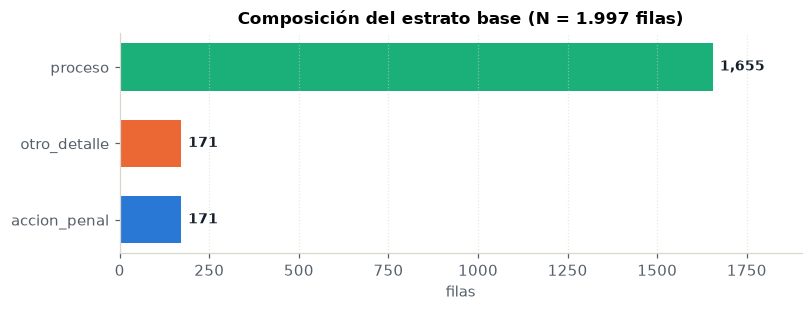

  proceso          1,655 filas  (82.9 %)
  otro_detalle       171 filas  ( 8.6 %)
  accion_penal       171 filas  ( 8.6 %)


In [3]:
comp = df["tipo_elemento_analitico"].value_counts()
pct = comp / len(df) * 100

fig, ax = plt.subplots(figsize=(8, 2.6))
ax.barh(comp.index[::-1], comp.values[::-1], color=[VERDE, NARANJA, AZUL][:len(comp)][::-1], height=.62)
etiquetar_barh(ax, comp.values[::-1])
ax.set_xlim(0, comp.max() * 1.15)
ax.set_title("Composición del estrato base (N = 1.997 filas)")
ax.set_xlabel("filas")
ax.grid(axis="y", visible=False)
plt.show()

for k, v in comp.items():
    print(f"  {k:<16} {v:>5,} filas  ({pct[k]:4.1f} %)")

## 2. Porcentaje de nulos, columna por columna

`clasificar_matriz_nulos` recorre las 87 columnas y para cada una calcula cuántos
nulos tiene, qué porcentaje representan y **a qué categoría de ausencia
corresponde**. Las categorías son el aporte real del paso: no describen cuánto
falta, sino por qué.

In [4]:
matriz = clasificar_matriz_nulos(df)
print(f"columnas auditadas: {len(matriz)}")

vista = matriz.copy()
vista["pct_nulos"] = (vista["pct_nulos"] * 100).round(1)
vista.head(20)[["columna", "n_nulos", "pct_nulos", "n_unicos", "tipo_dato", "categoria_nulo"]]

columnas auditadas: 87


,columna,n_nulos,pct_nulos,n_unicos,tipo_dato,categoria_nulo
24,conciliacion,1997,100.0,0,float64,estructural_materia
37,concluidas_extincion_prescripcion,1997,100.0,0,float64,estructural_materia
38,concluidas_sentencia_juicio,1997,100.0,0,float64,estructural_materia
25,num_juzgados,1997,100.0,0,Int64,estructural_materia
26,recibidas_otros_juzgados,1997,100.0,0,float64,estructural_materia
29,remision_art_299_ley_548,1997,100.0,0,float64,estructural_materia
31,remitidas_finalizacion_competencia,1997,100.0,0,float64,estructural_materia
33,reparacion_dano,1997,100.0,0,float64,estructural_materia
28,reparacion_dano_conciliacion,1997,100.0,0,float64,estructural_materia
34,sobreseimiento,1997,100.0,0,float64,estructural_materia


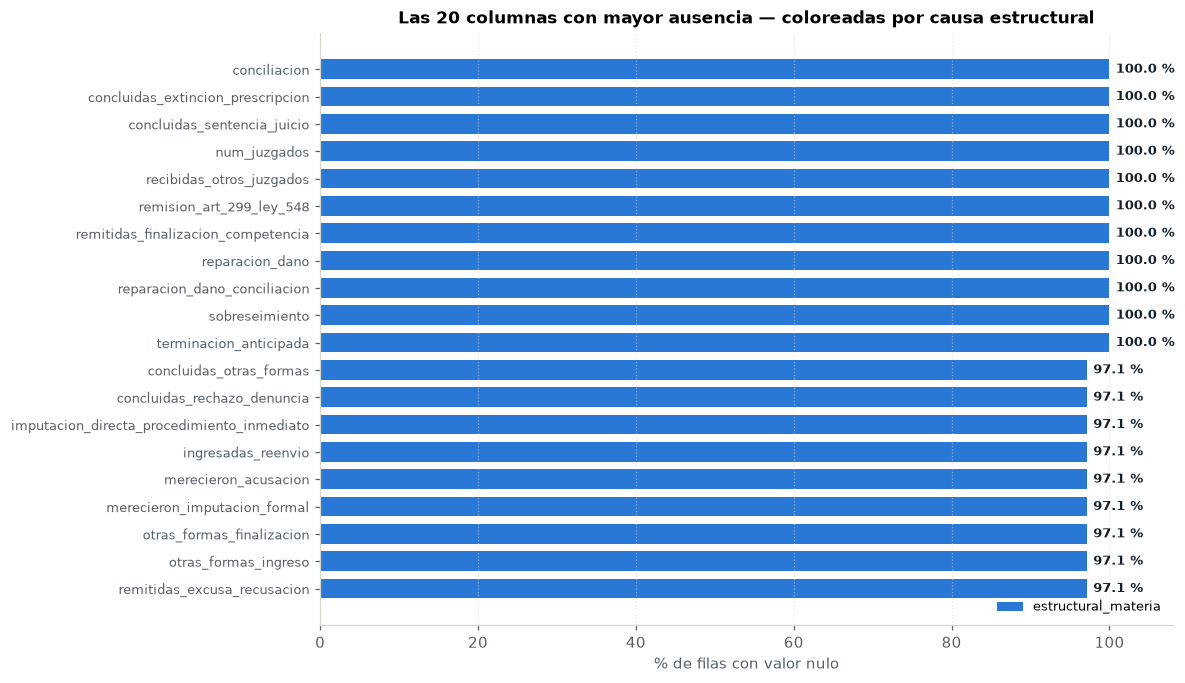

In [5]:
# Las veinte columnas con mayor porcentaje de ausencia.
top = matriz.head(20).iloc[::-1]
pcts = (top["pct_nulos"] * 100).values

colores_cat = {
    "estructural_materia": AZUL, "estructural_geografico": NARANJA,
    "estructural_recursos": VERDE, "estructural_tipo_elemento": AMBAR,
    "completa": "#9aa3ab", "otra_ausencia": "#9aa3ab",
}
cols = [colores_cat.get(c, "#9aa3ab") for c in top["categoria_nulo"]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(top)), pcts, color=cols, height=.72)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top["columna"], fontsize=8.5)
for i, v in enumerate(pcts):
    ax.text(v + 0.8, i, f"{v:.1f} %", va="center", fontsize=8.5, fontweight="bold", color=TINTA)
ax.set_xlim(0, 108)
ax.set_xlabel("% de filas con valor nulo")
ax.set_title("Las 20 columnas con mayor ausencia — coloreadas por causa estructural")
ax.grid(axis="y", visible=False)

from matplotlib.patches import Patch
presentes = [c for c in colores_cat if c in set(top["categoria_nulo"])]
ax.legend(handles=[Patch(facecolor=colores_cat[c], label=c) for c in presentes],
          loc="lower right", fontsize=8.5)
plt.show()

Casi todas las columnas de arriba llegan al 100 % de nulos, y ninguna es un
error: son columnas de un layout que no aplica a este estrato. Una columna
exclusiva de los cuadros penales está vacía en las filas civiles **por ley**, no
por un fallo de extracción.

In [6]:
resumen_cat = (matriz.groupby("categoria_nulo")
                     .agg(columnas=("columna", "count"),
                          nulos_promedio=("pct_nulos", "mean"))
                     .sort_values("columnas", ascending=False))
resumen_cat["pct_columnas"] = resumen_cat["columnas"] / len(matriz) * 100
resumen_cat["nulos_promedio"] = (resumen_cat["nulos_promedio"] * 100).round(1)
resumen_cat

,columnas,nulos_promedio,pct_columnas
categoria_nulo,,,
completa,47,0.0,54.022989
estructural_materia,34,92.1,39.080460
estructural_recursos,3,47.2,3.448276
estructural_geografico,2,50.0,2.298851
estructural_tipo_elemento,1,14.3,1.149425


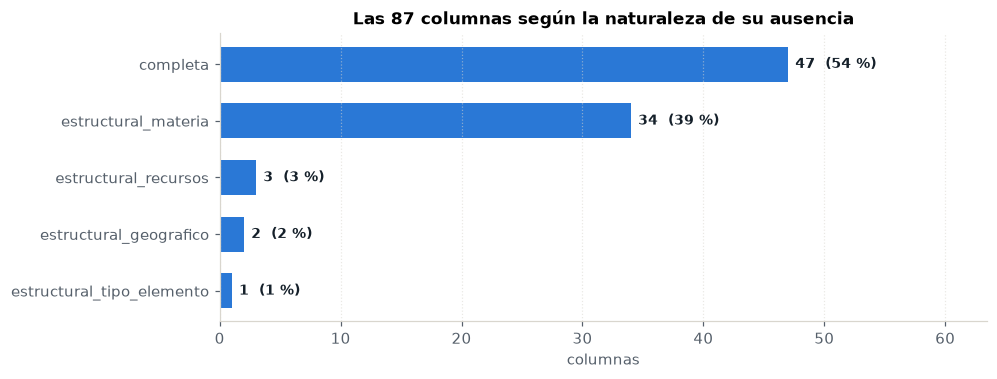

In [7]:
orden = resumen_cat.sort_values("columnas")
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.barh(orden.index, orden["columnas"].values, color=AZUL, height=.62)
for i, (n, p) in enumerate(zip(orden["columnas"].values, orden["pct_columnas"].values)):
    ax.text(n + 0.6, i, f"{n}  ({p:.0f} %)", va="center", fontsize=9,
            fontweight="bold", color=TINTA)
ax.set_xlim(0, orden["columnas"].max() * 1.35)
ax.set_xlabel("columnas")
ax.set_title(f"Las {len(matriz)} columnas según la naturaleza de su ausencia")
ax.grid(axis="y", visible=False)
plt.show()

## 3. Dinámica procesal: en qué estado quedó cada causa

`clasificar_dinamica_procesal` es el **primer tratamiento aditivo** de la capa
analítica: agrega la columna `estado_gestion` y no toca ninguna otra.

| estado | significa |
|---|---|
| `resolucion_total` | resueltas ≥ atendidas: el despacho cerró todo lo que gestionó |
| `con_resolucion_parcial` | resolvió algo, pero menos de lo que atendió |
| `en_tramite_exclusivo` | atendió causas y **no resolvió ninguna** en el año |
| `sin_movimiento` | cero causas atendidas |
| `encabezado_o_detalle` | no es un proceso: es una fila padre penal |

`en_tramite_exclusivo` es el estado que obliga a controlar la división por cero
en todas las tasas del paso 10.

In [8]:
df["estado_gestion"] = clasificar_dinamica_procesal(df)          # ← columna nueva
proc = df[df["tipo_elemento_analitico"] == "proceso"].copy()

conteo = proc["estado_gestion"].value_counts()
porcent = proc["estado_gestion"].value_counts(normalize=True) * 100
tabla_estados = pd.DataFrame({"procesos": conteo, "pct": porcent.round(1)})
tabla_estados

,procesos,pct
estado_gestion,,
con_resolucion_parcial,972,58.7
sin_movimiento,415,25.1
resolucion_total,150,9.1
en_tramite_exclusivo,118,7.1


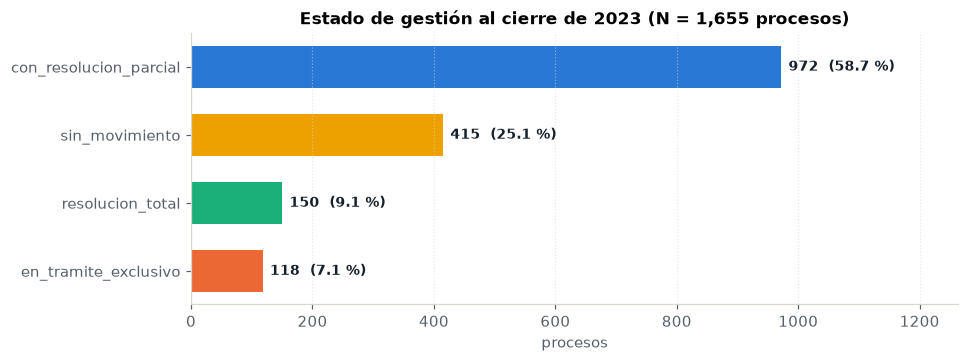

In [9]:
orden_e = conteo.sort_values()
colores_e = {"resolucion_total": VERDE, "con_resolucion_parcial": AZUL,
             "en_tramite_exclusivo": NARANJA, "sin_movimiento": AMBAR}

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(orden_e.index, orden_e.values,
        color=[colores_e.get(e, "#9aa3ab") for e in orden_e.index], height=.62)
for i, e in enumerate(orden_e.index):
    ax.text(orden_e[e] + 12, i, f"{orden_e[e]:,}  ({porcent[e]:.1f} %)", va="center",
            fontsize=9, fontweight="bold", color=TINTA)
ax.set_xlim(0, orden_e.max() * 1.3)
ax.set_xlabel("procesos")
ax.set_title(f"Estado de gestión al cierre de 2023 (N = {len(proc):,} procesos)")
ax.grid(axis="y", visible=False)
plt.show()

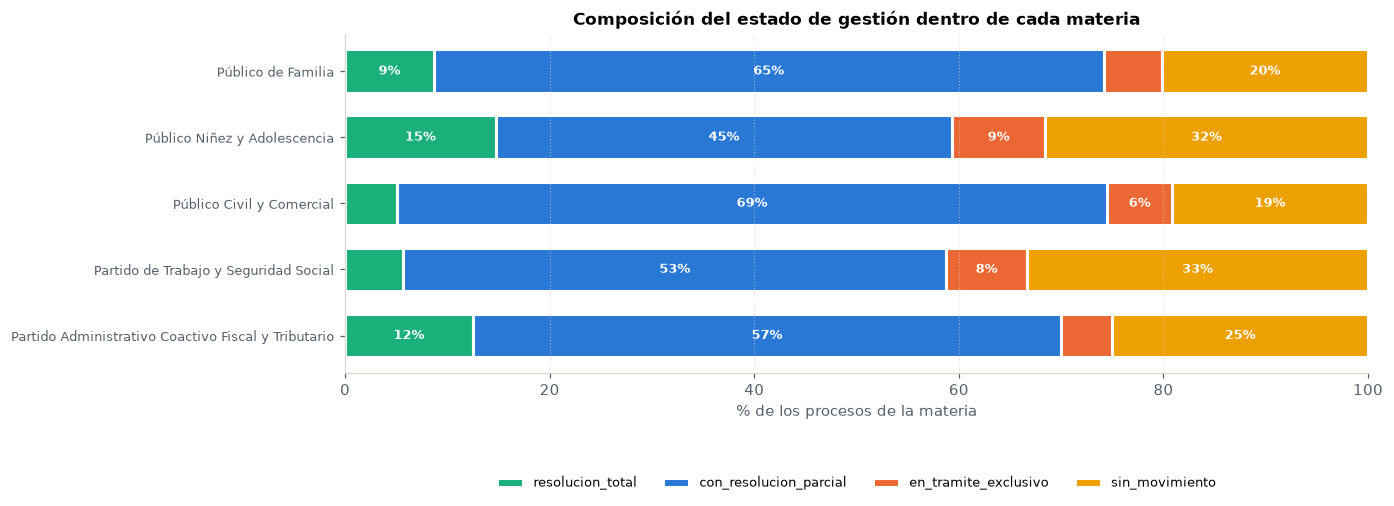

In [10]:
# El mismo corte, pero por materia y en proporción: dónde se concentra el trámite puro.
cruce = pd.crosstab(proc["materia_homologada"], proc["estado_gestion"])
cruce_pct = cruce.div(cruce.sum(axis=1), axis=0) * 100
cruce_pct = cruce_pct.loc[cruce_pct.sum(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(12, 4.0))
izq = np.zeros(len(cruce_pct))
for estado in ["resolucion_total", "con_resolucion_parcial", "en_tramite_exclusivo", "sin_movimiento"]:
    if estado not in cruce_pct.columns:
        continue
    vals = cruce_pct[estado].values
    ax.barh(range(len(cruce_pct)), vals, left=izq, height=.66,
            color=colores_e[estado], label=estado, edgecolor="white", linewidth=2)
    for i, (v, l) in enumerate(zip(vals, izq)):
        if v >= 6:
            ax.text(l + v / 2, i, f"{v:.0f}%", ha="center", va="center",
                    fontsize=8.5, fontweight="bold", color="white")
    izq += vals

ax.set_yticks(range(len(cruce_pct)))
ax.set_yticklabels(cruce_pct.index, fontsize=8.5)
ax.set_xlim(0, 100)
ax.set_xlabel("% de los procesos de la materia")
ax.set_title("Composición del estado de gestión dentro de cada materia")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower center", bbox_to_anchor=(.5, -.38), ncols=4, fontsize=8.5)
plt.show()

## 4. Control contable

El Anuario debería cumplir `atendidas == resueltas + pendientes_fin` en cada
fila. Esto no es una limpieza: es una verificación. Cuando falla, la regla del
repositorio es **registrar la discrepancia, no corregirla** — y por eso cada
fila viaja con su cuadro y su página, para poder ir a mirar el PDF.

In [11]:
con_datos = proc.dropna(subset=["resueltas", "pendientes_fin", "atendidas"])
dif = (con_datos["atendidas"] - (con_datos["resueltas"] + con_datos["pendientes_fin"])).abs()
descuadres = int((dif > 0).sum())

print(f"filas procesales verificadas : {len(con_datos):,}")
print(f"descuadres encontrados       : {descuadres}  "
      f"({descuadres / len(con_datos) * 100:.2f} % de las filas comparables)")

if descuadres:
    cols_traza = ["cuadro_origen", "pagina_pdf", "ambito", "territorio",
                  "materia_homologada", "tipo_proceso",
                  "atendidas", "resueltas", "pendientes_fin"]
    fallan = con_datos.loc[dif > 0, cols_traza].copy()
    fallan["esperado"] = fallan["resueltas"] + fallan["pendientes_fin"]
    fallan["diferencia"] = fallan["atendidas"] - fallan["esperado"]
    display(fallan)

filas procesales verificadas : 1,655
descuadres encontrados       : 1  (0.06 % de las filas comparables)


,cuadro_origen,pagina_pdf,ambito,territorio,materia_homologada,tipo_proceso,atendidas,resueltas,pendientes_fin,esperado,diferencia
1074,5.2.2.1,334,capital,ORURO,Partido Administrativo Coactivo Fiscal y Tribu...,CONTENCIOSO TRIBUTARIO,223,13,0,13,210


Aparece **una** fila que no cierra, y queda completamente localizada: cuadro
`5.2.2.1`, página 334 del PDF, Oruro, Contencioso Tributario. El Anuario publica
223 causas atendidas contra 13 resueltas y 0 pendientes al cierre — faltan 210
causas que la propia fuente no ubica en ningún lado.

No se toca. Es una discrepancia de la fuente, del mismo tipo que las 117 que el
paso 05 del ETL registra en `auditoria/discrepancias.csv`. Lo que sí importa es
saber que está ahí antes de calcular una tasa sobre esa fila.

## 5. Artefactos

Se escriben los mismos archivos que produce el script. El gráfico combina las
dos lecturas del paso: por qué faltan valores, y en qué estado quedaron las
causas.

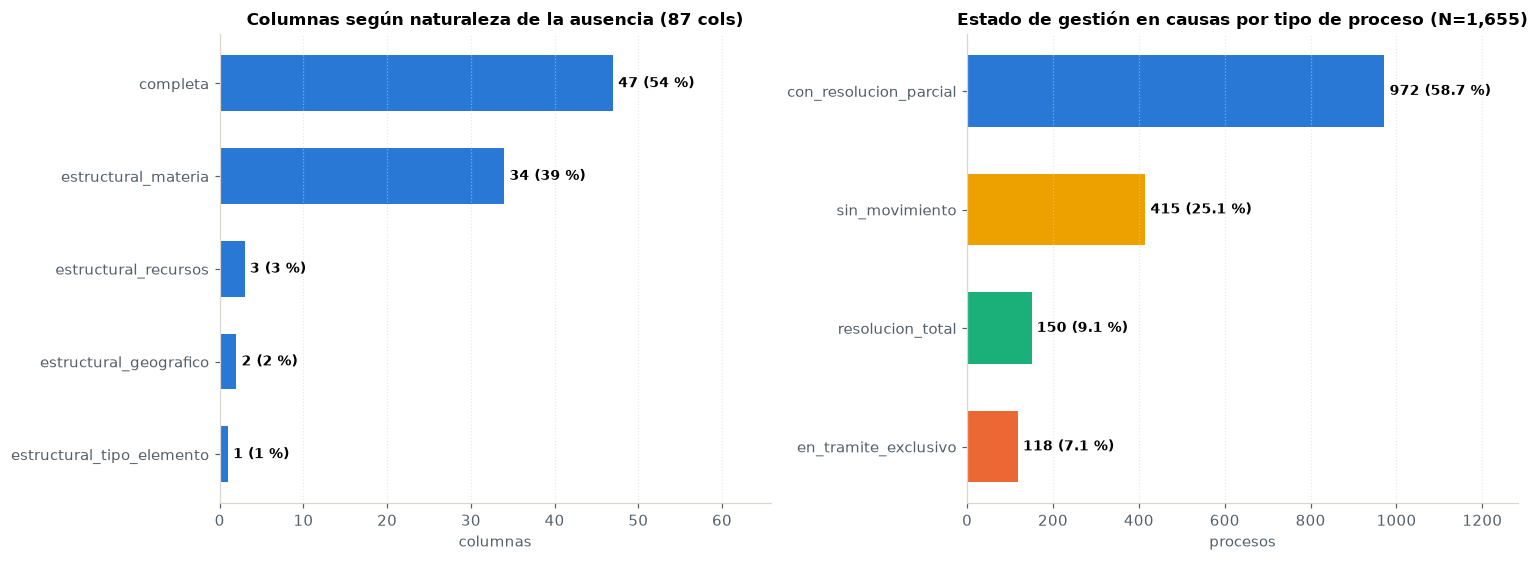

escritos:
  data/curated/eda/matriz_nulos_clasificada.csv
  data/curated/eda/resumen_dinamica_procesal.csv
  reports/figures/01_matriz_ausencias.png


In [12]:
matriz.to_csv(OUT_EDA / "matriz_nulos_clasificada.csv", index=False, encoding="utf-8")
pd.crosstab(proc["materia_homologada"], proc["estado_gestion"],
            margins=True, margins_name="Total").to_csv(
    OUT_EDA / "resumen_dinamica_procesal.csv", encoding="utf-8")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

o1 = resumen_cat.sort_values("columnas")
axes[0].barh(o1.index, o1["columnas"].values, color=AZUL, height=.6)
for i, (n, p) in enumerate(zip(o1["columnas"].values, o1["pct_columnas"].values)):
    axes[0].text(n + 0.6, i, f"{n} ({p:.0f} %)", va="center", fontsize=9, fontweight="bold")
axes[0].set_xlim(0, o1["columnas"].max() * 1.4)
axes[0].set_title(f"Columnas según naturaleza de la ausencia ({len(matriz)} cols)")
axes[0].set_xlabel("columnas")
axes[0].grid(axis="y", visible=False)

axes[1].barh(orden_e.index, orden_e.values,
             color=[colores_e.get(e, "#9aa3ab") for e in orden_e.index], height=.6)
for i, e in enumerate(orden_e.index):
    axes[1].text(orden_e[e] + 12, i, f"{orden_e[e]:,} ({porcent[e]:.1f} %)",
                 va="center", fontsize=9, fontweight="bold")
axes[1].set_xlim(0, orden_e.max() * 1.32)
axes[1].set_title(f"Estado de gestión en causas por tipo de proceso (N={len(proc):,})")
axes[1].set_xlabel("procesos")
axes[1].grid(axis="y", visible=False)

plt.tight_layout()
plt.savefig(OUT_FIG / "01_matriz_ausencias.png")
plt.show()

print("escritos:")
print("  data/curated/eda/matriz_nulos_clasificada.csv")
print("  data/curated/eda/resumen_dinamica_procesal.csv")
print("  reports/figures/01_matriz_ausencias.png")

---

**Lo que este paso no hizo:** no imputó un solo valor, no eliminó una sola fila
y no rellenó ningún nulo con cero. La única columna que agregó es
`estado_gestion`. Todo lo demás es descripción.